# Myanmar Conflict Network EDA

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import build_networks as bn # import pre-coded functions from the .py module build_networks

In [13]:
df = pd.read_csv('myanmar_data.csv')
df.shape

(39663, 33)

We keep only *Battles* and *Strategic developments*; violence against civilians is one-sided and not used for actor-actor ties.

In [14]:
df['event_type'].value_counts()

event_type
Battles                       18276
Strategic developments        14219
Violence against civilians     7168
Name: count, dtype: int64

In [15]:
df = df[df['event_type'] != 'Violence against civilians']

Check most active actors

In [16]:
df['actor1'].value_counts().head(50)

actor1
Military Forces of Myanmar (2021-)                                                                 17623
KIO/KIA: Kachin Independence Organization/Kachin Independence Army                                  1098
KNU/KNLA: Karen National Union/Karen National Liberation Army                                        900
ULA/AA: United League of Arakan/Arakan Army                                                          857
Unidentified Armed Group (Myanmar)                                                                   669
Unidentified Anti-Coup Armed Group                                                                   653
PSLF/TNLA: Palaung State Liberation Front/Ta'ang National Liberation Army                            463
Police Forces of Myanmar (2021-)                                                                     433
MNTJP/MNDAA: Myanmar National Truth and Justice Party/Myanmar National Democratic Alliance Army      267
People's Defense Force - Myaing                 

Each event has two sides: `actor1` + `assoc_actor_1` vs `actor2` + `assoc_actor_2` (associated actors are `;`-separated).

In [17]:
events = bn.load_events('myanmar_data.csv')
events.head()

,event_date,event_type,actor1,assoc_actor_1,actor2,assoc_actor_2
0,2021-05-05,Strategic developments,Military Forces of Myanmar (2021-),NaN,Civilians (Myanmar),NaN
1,2021-05-05,Strategic developments,RCSS/SSA-S: Restoration Council of Shan State/...,PSLF/TNLA: Palaung State Liberation Front/Ta'a...,Civilians (Myanmar),NaN
2,2021-05-05,Battles,Military Forces of Myanmar (2021-),NaN,KNU/KNLA: Karen National Union/Karen National ...,NaN
3,2021-05-05,Battles,Military Forces of Myanmar (2021-),NaN,KIO/KIA: Kachin Independence Organization/Kach...,NaN
4,2021-05-05,Battles,Military Forces of Myanmar (2021-),NaN,NA-B: Northern Alliance,NaN


Rows with all actor fields filled (multi-actor events):

In [18]:
events[events.notna().all(axis=1)].sample(5, random_state=0)

,event_date,event_type,actor1,assoc_actor_1,actor2,assoc_actor_2
15369,2023-02-08,Battles,People's Defense Force - Minbu District,People's Defence Force - Salin; People's Defen...,Military Forces of Myanmar (2021-),Police Forces of Myanmar (2021-)
9411,2022-06-28,Strategic developments,Military Forces of Myanmar (2021-),Police Forces of Myanmar (2021-),Civilians (Myanmar),Teachers (Myanmar)
5152,2022-01-13,Battles,CNF/CNA: Chin National Front/Chin National Army,CDF: Chinland Defense Force,Meithei Kathe Ethnic Militia (Myanmar),Unidentified Armed Group (Myanmar)
14549,2023-01-08,Battles,Snake Eyes - PDF (Shwebo),Unidentified Anti-Coup Armed Group,Military Forces of Myanmar (2021-),Pyu Saw Htee
10535,2022-08-10,Strategic developments,Military Forces of Myanmar (2021-),Pyu Saw Htee,Civilians (Myanmar),Buddhist Group (Myanmar)


Unique armed actors (non-combatant groups removed) and how many pass each activity threshold. The long tail of small local units is why we keep only the top-50.

In [19]:
actor_counts = pd.Series(bn.count_actors(bn.event_sides(events))).sort_values(ascending=False)
print('Unique armed actors:', len(actor_counts))
print(f'Top-50 share of actor appearances: {actor_counts.head(50).sum() / actor_counts.sum():.0%}')

pd.DataFrame({'min_events': t, 'actors': (actor_counts >= t).sum()} for t in [1, 2, 5, 10, 20, 50, 100])

Unique armed actors: 2788
Top-50 share of actor appearances: 69%


,min_events,actors
0,1,2788
1,2,2009
2,5,1240
3,10,754
4,20,383
5,50,129
6,100,62


For the top-50 actors: same-side co-occurrence → **friendship**, opposite-side → **conflict**. Pairs that appear as both are dropped. Edge weight = number of events.

In [20]:
conflict_G, friendship_G = bn.build_networks(events, top_n=50)
print('conflict:  ', conflict_G)
print('friendship:', friendship_G)

conflict:   Graph with 50 nodes and 185 edges
friendship: Graph with 50 nodes and 170 edges


Strongest ties:

In [21]:
import networkx as nx

display(nx.to_pandas_edgelist(conflict_G).nlargest(10, 'weight'))
display(nx.to_pandas_edgelist(friendship_G).nlargest(10, 'weight'))

,source,target,weight
12,Military Forces of Myanmar (2021-),Unidentified Anti-Coup Armed Group,3359
4,Military Forces of Myanmar (2021-),KIO/KIA: Kachin Independence Organization/Kach...,1595
27,Military Forces of Myanmar (2021-),KNU/KNLA: Karen National Union/Karen National ...,1578
18,Military Forces of Myanmar (2021-),ULA/AA: United League of Arakan/Arakan Army,1279
17,Military Forces of Myanmar (2021-),PSLF/TNLA: Palaung State Liberation Front/Ta'a...,792
19,Military Forces of Myanmar (2021-),KNDF: Karenni Nationalities Defense Force,743
20,Military Forces of Myanmar (2021-),MNTJP/MNDAA: Myanmar National Truth and Justic...,510
40,Unidentified Anti-Coup Armed Group,Pyu Saw Htee,450
30,Military Forces of Myanmar (2021-),KNPP/KA: Karenni National Progressive Party/Ka...,435
34,Military Forces of Myanmar (2021-),NLD: National League for Democracy,367


,source,target,weight
47,KNU/KNLA: Karen National Union/Karen National ...,PDF: People's Defense Force,396
93,KNDF: Karenni Nationalities Defense Force,KNPP/KA: Karenni National Progressive Party/Ka...,377
42,KIO/KIA: Kachin Independence Organization/Kach...,PDF: People's Defense Force,286
40,KIO/KIA: Kachin Independence Organization/Kach...,KPDF: Kachin Region People's Defense Force,246
16,Unidentified Anti-Coup Armed Group,KIO/KIA: Kachin Independence Organization/Kach...,225
95,KNDF: Karenni Nationalities Defense Force,People's Defense Force - Demoso,114
0,Unidentified Anti-Coup Armed Group,KNDF: Karenni Nationalities Defense Force,96
45,KNU/KNLA: Karen National Union/Karen National ...,Cobra Column,95
92,KNDF: Karenni Nationalities Defense Force,People's Defense Force - Pekon,87
101,NLD: National League for Democracy,Government of Myanmar (2016-),87


Node colours = activity-rank groups (≈9 actors each).

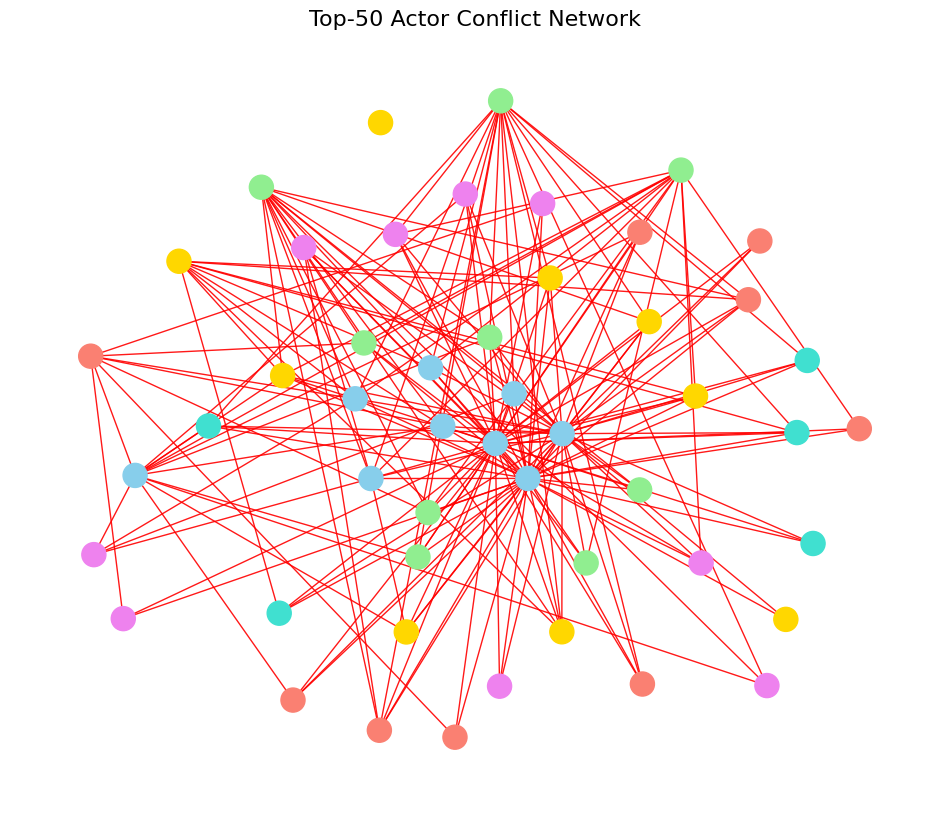

In [22]:
bn.plot_network(conflict_G, 'Top-50 Actor Conflict Network', 'red')
plt.show()

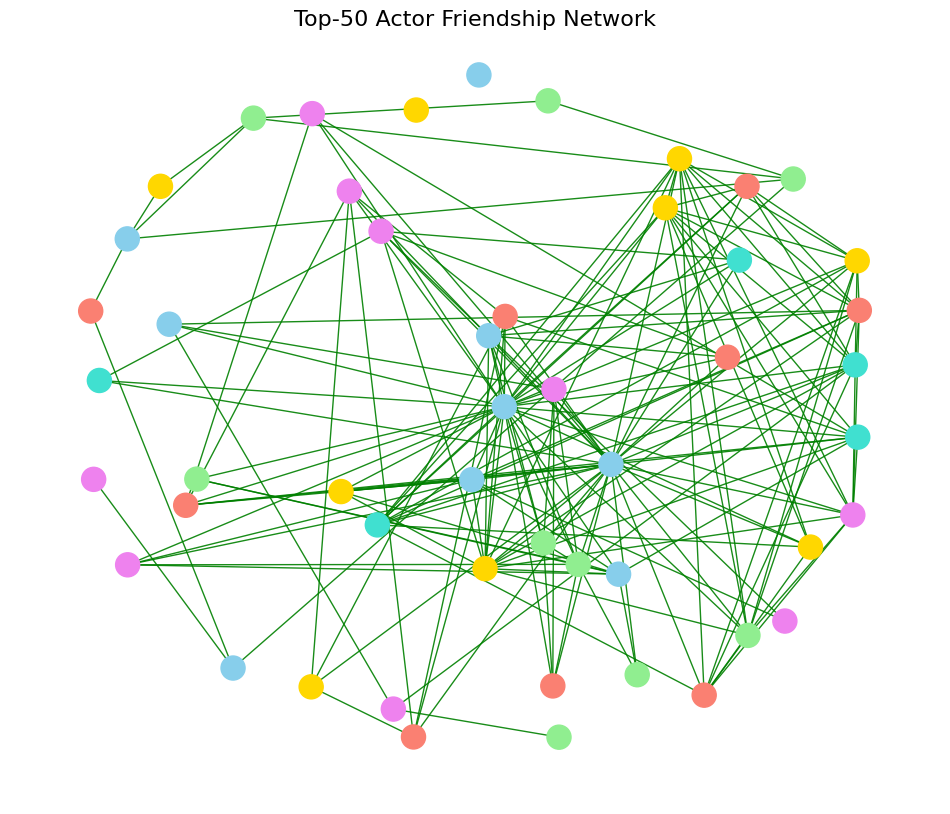

In [23]:
bn.plot_network(friendship_G, 'Top-50 Actor Friendship Network', 'green')
plt.show()